# Gliner2 training on archaeological NER data


### Colab Configuration Requirements
To run this notebook on Google Colab, add the following secrets to your environment (Key icon in the left sidebar):
#### 1. Repository Access
* **`GITHUB_TOKEN`**: Required for cloning private source code.
* **Obtain**: [GitHub Settings](https://github.com/settings/tokens) > Developer Settings > Personal access tokens. Required scope: `repo` or `contents:read`.
#### 2. Argilla Integration
Retrievable from your Argilla instance profile page:
* **`ARGILLA_API_URL`**: Instance endpoint.
* **`ARGILLA_API_KEY`**: Personal API key.
* **`ARGILLA_WORKSPACE`**: Target workspace.
* **`ARGILLA_DATASET`**: Dataset name.
* **`ANNOTATOR_A`**: Username associated with your annotations.
#### 3. Activation
* Toggle **Notebook access** to **ON** for all listed secrets.

## Init

In [ ]:
import os
import sys
import subprocess
from pathlib import Path

# 1. Environment Detection & Pre-Import Setup
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print(">>> Environment: Google Colab")
    from google.colab import userdata

    # Install dependencies BEFORE importing them
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "gliner2", "argilla", "tabulate", "python-dotenv",
                           "matplotlib", "seaborn", "scikit-learn", "mammoth", "markdownify", "wtpsplit"])

    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    REPO_NAME = "archaeo-ner-greek"
    REPO_URL = f"https://{GITHUB_TOKEN}@github.com/prokopidis/{REPO_NAME}.git"
    if not os.path.exists(REPO_NAME):
        print(f"Cloning repository: {REPO_URL} into {REPO_NAME}")
        # Use subprocess.check_call for robust cloning and error handling
        subprocess.check_call(["git", "clone", "--branch", "dev", REPO_URL])
    else:
        print(f"Repository {REPO_NAME} already exists. Skipping clone.")

    # Add repo to path and adjust working directory
    # Using absolute path resolution for safety
    REPO_PATH = Path(os.getcwd()) / REPO_NAME
    if str(REPO_PATH) not in sys.path:
        sys.path.append(str(REPO_PATH))

    # Ensure the repository directory exists before changing into it
    if not REPO_PATH.is_dir():
        raise FileNotFoundError(f"Repository directory not found at {REPO_PATH} after cloning attempt.")

    os.chdir(str(REPO_PATH))

    # Load Colab Secrets

    def get_secret(key):
        try: return userdata.get(key)
        except: return None

    env_vars = {
        "ARGILLA_API_URL": get_secret("ARGILLA_API_URL"),
        "ARGILLA_API_KEY": get_secret("ARGILLA_API_KEY"),
        "ARGILLA_WORKSPACE": get_secret("ARGILLA_WORKSPACE"),
        "ARGILLA_DATASET": get_secret("ARGILLA_DATASET"),
        "ANNOTATOR_A": get_secret("ANNOTATOR_A"),
    }
else:
    print(">>> Environment: Local")
    from dotenv import dotenv_values, find_dotenv
    env_path = find_dotenv()
    env_vars = dotenv_values(env_path) if env_path else {}

# 2. Optimized Imports (Now safe because packages are installed/pathed)
import json
import logging
import warnings
import random
from datetime import datetime
from logging.config import dictConfig

from tabulate import tabulate
import matplotlib.pyplot as plt

import torch
from gliner2 import GLiNER2
from gliner2.training.data import InputExample, TrainingDataset
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Local project imports
import archaeo_ner_greek
from archaeo_ner_greek.logging_config import LOGGING_CONFIG
from archaeo_ner_greek.utils import (
    configure_argilla_client,
    get_dataset_as_dataframe,
)

# 3. Path Management
BASE_DIR = Path(os.getcwd())
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = DATA_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 4. Logging & Global Config
dictConfig(LOGGING_CONFIG)
logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")
warnings.filterwarnings("ignore", category=DeprecationWarning, message=".*SwigPyObject.*")

print(f">>> Working Directory: {BASE_DIR}")
print(f">>> Models Directory:  {MODELS_DIR}")

>>> Environment: Local
>>> Working Directory: /home/prokopis/src/archaeo-ner-greek/notebooks
>>> Models Directory:  /home/prokopis/src/archaeo-ner-greek/notebooks/data/models


## Data Loading and Preprocessing


In [2]:
DEFAULT_ANNOTATOR = env_vars.get("ANNOTATOR_A")
df_annotated = get_dataset_as_dataframe(
    client=configure_argilla_client(env_vars=env_vars),
    dataset_name=env_vars.get("ARGILLA_DATASET"),
    workspace_name=env_vars.get("ARGILLA_WORKSPACE"), 
    username=DEFAULT_ANNOTATOR
)
if not df_annotated.empty:
    logger.info(f"Ready: {len(df_annotated)} samples loaded with 'labels' ready for training.")
    logger.info(f"Available Columns: {df_annotated.columns.tolist()}")

if not df_annotated.empty:
    row = df_annotated.iloc[0]
    logger.info(f"{'='*40} FULL ROW DEBUG {'='*40}")
    logger.info(f"ID     : {row['id']}")
    logger.info(f"Full Response Dict: {json.dumps(row['sentence_field'], indent=2, ensure_ascii=False)}")
    logger.info(f"Labels (Extracted): {row['labels']}")
    logger.debug(f"Full Response Dict: {json.dumps(row['response'], indent=2, ensure_ascii=False)}")

2026-04-10 17:14:49,195 [INFO]: Argilla: Logged in as prokopis with the role Role.owner (root:157)
2026-04-10 17:14:49,429 [INFO]: Ready: 212 samples loaded with 'labels' ready for training. (__main__:9)
2026-04-10 17:14:49,430 [INFO]: Available Columns: ['id', 'prev_sentences_field', 'sentence_field', 'next_sentences_field', 'document_sentence_id_field', 'sentence_id_metadata', 'responses', 'response', 'labels'] (__main__:10)
2026-04-10 17:14:49,431 [INFO]: ======================================== FULL ROW DEBUG ======================================== (__main__:14)
2026-04-10 17:14:49,431 [INFO]: ID     : 1f381dd6-d643-407c-af7c-e9365d9b07af (__main__:15)
2026-04-10 17:14:49,432 [INFO]: Full Response Dict: "Αργυρή δραχμή Απολλωνίας από την Ελέα" (__main__:16)
2026-04-10 17:14:49,432 [INFO]: Labels (Extracted): [{'label': 'LOCATION', 'start': 33, 'end': 37}, {'label': 'MATERIAL', 'start': 0, 'end': 6}, {'label': 'ARTEFACT', 'start': 7, 'end': 25}] (__main__:17)


### Guidelines to entities descriptions 

In [3]:
# Dynamically find the package resources folder
PACKAGE_ROOT = Path(archaeo_ner_greek.__file__).parent
RESOURCES_DIR = PACKAGE_ROOT / "resources"
GUIDELINES_PATH = RESOURCES_DIR / "guidelines_en.json"
logger.info(f"Loading entity descriptions from {GUIDELINES_PATH}")
with open(GUIDELINES_PATH, 'r', encoding='utf-8') as f:
    entity_descriptions = json.load(f)

logger.info(f"Labels: {list(entity_descriptions.keys())}")
logger.info(f"Example: ARTEFACT: {entity_descriptions['ARTEFACT']}")

2026-04-10 17:14:49,500 [INFO]: Loading entity descriptions from /home/prokopis/src/archaeo-ner-greek/archaeo_ner_greek/resources/guidelines_en.json (__main__:5)
2026-04-10 17:14:49,502 [INFO]: Labels: ['ARTEFACT', 'PERIOD', 'LOCATION', 'CONTEXT', 'MATERIAL', 'SPECIES', 'PERSON', 'FEATURE'] (__main__:9)
2026-04-10 17:14:49,502 [INFO]: Example: ARTEFACT: any type of archaeological find,Regardless of size. Includes detached architectural members like «κιονόκρανο», «θριγκὸ» or objects like «διπλός πέλεκυς», «αναθηματική στήλη». (__main__:10)


### Training examples

In [4]:
train_examples = []
for _, row in df_annotated.iterrows():
    text = row['sentence_field']

    entities = {}
    for lbl in entity_descriptions.keys():
        entities[lbl] = [] # All labels are present in the InputExample, even if no instances for the label have been found

    labels = row.get('labels', [])
    for label_obj in labels:
        lbl = label_obj['label']
        start = label_obj['start']
        end = label_obj['end']
        mention = text[start:end].strip()
        # if lbl not in entities:
        #     entities[lbl] = []
        entities[lbl].append(mention) # This will crash, if the lbl is not a key in entity_descriptions.
    
    train_examples.append(InputExample(
        text=text,
        entities=entities,
        entity_descriptions=entity_descriptions,                
    ))

logger.info(f"Text: {train_examples[20].text}")
logger.info(f"Entities: {train_examples[20].entities}")
logger.info(train_examples[20].entities)
logger.info(f'Entity descriptions example: ARTEFACT: {train_examples[20].entity_descriptions["ARTEFACT"]}')
logger.info(train_examples[20])

2026-04-10 17:14:49,557 [INFO]: Text: Ὁρισμένες οἰκίες τῆς « μυκηναϊκῆς » φάσης εἶχαν λιθόστρωτα δάπεδα , κάτω ἀπὸ τὰ ὁποῖα ( ὅπως καὶ σὲ ἐλεύθερους χώρους μεταξὺ τῶν κτιρίων ) ἐντοπίστηκαν κυκλικοὶ καὶ ὀρθογώνιοι ταφικοὶ λάκκοι , οἱ ὁποῖοι σημειώνονται μὲ τὸ γράμμα Λ στὸ δημοσιευμένο σχέδιο ( εἰκ . 3) . (__main__:25)
2026-04-10 17:14:49,558 [INFO]: Entities: {'ARTEFACT': [], 'PERIOD': ['« μυκηναϊκῆς » φάσης'], 'LOCATION': [], 'CONTEXT': ['δάπεδα', 'ταφικοὶ λάκκοι'], 'MATERIAL': ['λιθόστρωτα'], 'SPECIES': [], 'PERSON': [], 'FEATURE': []} (__main__:26)
2026-04-10 17:14:49,558 [INFO]: {'ARTEFACT': [], 'PERIOD': ['« μυκηναϊκῆς » φάσης'], 'LOCATION': [], 'CONTEXT': ['δάπεδα', 'ταφικοὶ λάκκοι'], 'MATERIAL': ['λιθόστρωτα'], 'SPECIES': [], 'PERSON': [], 'FEATURE': []} (__main__:27)
2026-04-10 17:14:49,558 [INFO]: Entity descriptions example: ARTEFACT: any type of archaeological find,Regardless of size. Includes detached architectural members like «κιονόκρανο», «θριγκὸ» or objects like «διπλός

In [5]:
train_dataset = TrainingDataset(train_examples)
train_dataset.validate(raise_on_error=True)

# The following may throw away one example (Gliner2 bug)
# train_split, val_split, _ = train_dataset.split( 
#     train_ratio=0.9, 
#     val_ratio=0.1, 
#     test_ratio=0.0, 
#     shuffle=True, 
#     seed=42
# )

all_examples = train_dataset.examples.copy()
random.seed(42)
random.shuffle(all_examples)
val_size = int(len(all_examples) * 0.1) 
val_split = all_examples[:val_size]      
train_split = all_examples[val_size:]   
print(f"Train: {len(train_split)} | Val: {len(val_split)} | Total: {len(train_split) + len(val_split)}")
train_split = TrainingDataset(train_split)
val_split = TrainingDataset(val_split)


for ds_name, ds in {"full": train_dataset, "train": train_split, "val":val_split}.items():
    print(f"Dataset: {ds_name} ")
    ds.print_stats()
    logger.debug(ds[0])

Train: 191 | Val: 21 | Total: 212
Dataset: full 

GLiNER2 Training Dataset Statistics
Total examples: 212

Text lengths: min=6, max=666, mean=136.1

Task Distribution:
  entities_only: 212 (100.0%)

Entity Types (819 total mentions):
  CONTEXT: 249
  ARTEFACT: 201
  MATERIAL: 100
  PERIOD: 91
  FEATURE: 86
  LOCATION: 46
  PERSON: 25
  SPECIES: 21

Dataset: train 

GLiNER2 Training Dataset Statistics
Total examples: 191

Text lengths: min=9, max=666, mean=135.6

Task Distribution:
  entities_only: 191 (100.0%)

Entity Types (727 total mentions):
  CONTEXT: 224
  ARTEFACT: 173
  MATERIAL: 87
  PERIOD: 83
  FEATURE: 79
  LOCATION: 38
  PERSON: 24
  SPECIES: 19

Dataset: val 

GLiNER2 Training Dataset Statistics
Total examples: 21

Text lengths: min=6, max=485, mean=140.9

Task Distribution:
  entities_only: 21 (100.0%)

Entity Types (92 total mentions):
  ARTEFACT: 28
  CONTEXT: 25
  MATERIAL: 13
  PERIOD: 8
  LOCATION: 8
  FEATURE: 7
  SPECIES: 2
  PERSON: 1



# Training

## Custom metrics for evaluation

In [6]:
THRESHOLD = 0.8

def compute_metrics(model, dataset, threshold=THRESHOLD):
    """Bulleted Micro-F1 calculation with local path-based schema loading."""
    tp, fp, fn = 0, 0, 0
    model.eval()

    for i, ex in enumerate(dataset):
        logger.debug(ex)
        # Inference
        text = ex[0]
        gt_entities = ex[1]["entities"] # Ground truth entities
        entity_descriptions = ex[1]["entity_descriptions"]

        output = model.extract_entities(text, entity_descriptions, threshold=threshold)
        pred_entities = output.get('entities', {})
        
        # Flatten pred spans
        pred_spans = []
        for lbl, texts in pred_entities.items():
            for t in texts:
                pred_spans.append((t, lbl))
        
        # Flatten gt spans
        gt_spans = []
        for lbl, texts in gt_entities.items():
            for t in texts:
                gt_spans.append((t, lbl))
        
        # Exact Match logic (order insensitive)
        temp_gt = gt_spans.copy()
        for p in pred_spans:
            if p in temp_gt:
                tp += 1
                temp_gt.remove(p)
            else:
                fp += 1
        fn += len(temp_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics = {"f1": f1, "precision": precision, "recall": recall, "tp": tp, "fp": fp, "fn": fn}
    formatted_metrics = {k: (f"{v:.4f}" if isinstance(v, float) else v) for k, v in metrics.items()}
    print(f"\n>>> EVAL: {formatted_metrics}")
    sys.stdout.flush()
    
    return metrics


## Training config

In [7]:
experiment_name = f"gliner2_archaeo_lora_{datetime.now().strftime('%Y%m%d_%H%M')}"
output_dir = DATA_DIR / "models" / experiment_name
output_dir.mkdir(parents=True, exist_ok=True)
num_epochs = 30


training_config = TrainingConfig(
    output_dir=str(output_dir),
    experiment_name=experiment_name,
    seed=42,
    
    # Hardware & Batching Stability 
    batch_size=1,
    eval_batch_size=1,             # Prevents "tensor size mismatch" during evaluation
    gradient_accumulation_steps=4, # Simulates Effective Batch Size = 4
    fp16=True,                     # Half-precision for speed/memory
    
    # LoRA Architecture (Rank 4 for stability on small datasets)
    use_lora=True,
    lora_r=4,                     # Reduced from 16
    lora_alpha=8.0,               # Reduced from 32.0 (standard 2*r)
    lora_dropout=0.1,             # Regularization for small datasets
    lora_target_modules=["encoder"], # Focused target
    save_adapter_only=True,        # Saves ~10-30MB instead of 1.2GB per checkpoint

    # Optimization Profile
    num_epochs=num_epochs,
    task_lr=1e-4,                 # Primary learning rate for adapters/heads
    warmup_ratio=0.1,
    scheduler_type="cosine",       # Smooth decay for stable convergence
    weight_decay=0.01,


    # Checkpointing (Accuracy follows F1)
    eval_strategy="epoch",
    save_best=True,
    metric_for_best="f1",        # Use F1 to drive selection
    greater_is_better=True,      # Higher is better
    # metric_for_best="eval_loss", # Use Loss to drive selection
    # greater_is_better=False,      # Lower is better
    save_total_limit=2,
    logging_steps=5,
       
    # Early Stopping (DISABLED due to gliner2 v1.2.5 bug)
    early_stopping=False,
    early_stopping_patience=10,

    # Data Handling
    validate_data=True,
)

## Trainer

In [8]:
model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1") # Multi-tasking, multilingual
trainer = GLiNER2Trainer(model, training_config, compute_metrics=compute_metrics)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute


🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first
2026-04-10 17:14:54,313 [INFO]: Using device: cuda (gliner2.training.trainer:580)
2026-04-10 17:14:54,315 [INFO]: Setting up LoRA for parameter-efficient fine-tuning... (gliner2.training.trainer:622)
2026-04-10 17:14:54,317 [INFO]: Froze all model parameters for LoRA training (gliner2.training.trainer:627)
2026-04-10 17:14:54,336 [INFO]: Applied LoRA to 72 layers (gliner2.training.lora:401)
🔧 LoRA Configuration
Enabled            : True
Rank (r)           : 4
Alpha              : 8.0
Scaling (α/r)      : 2.0000
Dropout            : 0.1
Target modules     : encoder
LoRA layers        : 72
----------------------------------------------------------------------
Trainable params   : 663,552 / 307,762,197 (0.22%)
Memory savings     : ~99.8% fewer gradients
2026-04-10 17:14:54,338 [INFO]: LoRA setup complete: 663,552 trainable params out of 307,762,197 total (0.22%)

## Train run

In [9]:
results = trainer.train(
    train_data=train_split, 
    eval_data=val_split
)

Validating records: 100%|██████████| 191/191 [00:00<00:00, 127201.03record/s]

2026-04-10 17:14:54,380 [INFO]: Optimizer: LoRA params only = 144, LR=0.0001 (gliner2.training.trainer:769)
2026-04-10 17:14:54,380 [INFO]: ***** Running Training ***** (gliner2.training.trainer:906)
2026-04-10 17:14:54,380 [INFO]:   Num examples = 191 (gliner2.training.trainer:907)
2026-04-10 17:14:54,381 [INFO]:   Num epochs = 30 (gliner2.training.trainer:908)
2026-04-10 17:14:54,381 [INFO]:   Batch size = 1 (gliner2.training.trainer:909)
2026-04-10 17:14:54,381 [INFO]:   Gradient accumulation steps = 4 (gliner2.training.trainer:910)
2026-04-10 17:14:54,381 [INFO]:   Effective batch size = 4 (gliner2.training.trainer:911)
2026-04-10 17:14:54,382 [INFO]:   Total optimization steps = 1410 (gliner2.training.trainer:912)
2026-04-10 17:14:54,382 [INFO]:   Warmup steps = 141 (gliner2.training.trainer:913)
2026-04-10 17:14:54,383 [INFO]:   LoRA enabled: 663,552 trainable / 307,762,197 total (0.22%) (gliner2.training.trainer:918)


Training:   0%|          | 0/1410 [00:00<?, ?it/s]

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=160729) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


2026-04-10 17:15:03,767 [INFO]: Flushed incomplete gradient accumulation cycle at end of epoch (grad_norm: 10.17) (gliner2.training.trainer:738)
2026-04-10 17:15:03,769 [INFO]: Applied incomplete gradient accumulation at end of epoch 1 (gliner2.training.trainer:1036)
2026-04-10 17:15:03,770 [INFO]: Epoch 1/30 - Loss: 3.1465 (gliner2.training.trainer:1040)
2026-04-10 17:15:03,771 [INFO]: Running evaluation... (gliner2.training.trainer:1078)


...


>>> EVAL: {'f1': '0.7326', 'precision': '0.7875', 'recall': '0.6848', 'tp': 63, 'fp': 17, 'fn': 29}
2026-04-10 17:27:22,202 [INFO]: Saved 144 LoRA tensors to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-28/adapter_weights.safetensors (gliner2.training.lora:660)
2026-04-10 17:27:22,204 [INFO]: Saved adapter config to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-28/adapter_config.json (gliner2.training.lora:116)
2026-04-10 17:27:22,204 [INFO]: Saved LoRA adapter to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-28 (gliner2.training.lora:687)
2026-04-10 17:27:22,205 [INFO]: 💾 Saved adapter checkpoint 'checkpoint-epoch-28' | step 1344 | epoch 28.0 | 663,552 params | 2.5MB | 0.0s (gliner2.training.trainer:1269)
2026-04-10 17:27:22,206 [INFO]: Removed old checkpoint: checkpoint-epoch-26 (gliner2.tr

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


>>> EVAL: {'f1': '0.7326', 'precision': '0.7875', 'recall': '0.6848', 'tp': 63, 'fp': 17, 'fn': 29}
2026-04-10 17:27:51,592 [INFO]: Saved 144 LoRA tensors to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-29/adapter_weights.safetensors (gliner2.training.lora:660)
2026-04-10 17:27:51,594 [INFO]: Saved adapter config to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-29/adapter_config.json (gliner2.training.lora:116)
2026-04-10 17:27:51,594 [INFO]: Saved LoRA adapter to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-29 (gliner2.training.lora:687)
2026-04-10 17:27:51,595 [INFO]: 💾 Saved adapter checkpoint 'checkpoint-epoch-29' | step 1392 | epoch 29.0 | 663,552 params | 2.5MB | 0.0s (gliner2.training.trainer:1269)
2026-04-10 17:27:51,597 [INFO]: Removed old checkpoint: checkpoint-epoch-27 (gliner2.tr

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


>>> EVAL: {'f1': '0.7326', 'precision': '0.7875', 'recall': '0.6848', 'tp': 63, 'fp': 17, 'fn': 29}
2026-04-10 17:27:56,090 [INFO]: Saved 144 LoRA tensors to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-30/adapter_weights.safetensors (gliner2.training.lora:660)
2026-04-10 17:27:56,091 [INFO]: Saved adapter config to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-30/adapter_config.json (gliner2.training.lora:116)
2026-04-10 17:27:56,092 [INFO]: Saved LoRA adapter to /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/checkpoint-epoch-30 (gliner2.training.lora:687)
2026-04-10 17:27:56,093 [INFO]: 💾 Saved adapter checkpoint 'checkpoint-epoch-30' | step 1410 | epoch 30.0 | 663,552 params | 2.5MB | 0.0s (gliner2.training.trainer:1269)
2026-04-10 17:27:56,094 [INFO]: Removed old checkpoint: checkpoint-epoch-28 (gliner2.tr

# Analysis

## Training details

In [ ]:
best_run = max(results["eval_metrics_history"], key=lambda x: x['f1'])
best_epoch = best_run['epoch']
best_p = best_run['precision']
best_r = best_run['recall']
best_f1 = best_run['f1']
total_epochs = len(results["eval_metrics_history"])
def get_cnt(data):
    exs = getattr(data, "examples", data)
    return sum(len(mentions) for ex in exs for mentions in ex.entities.values())

print(f"Training completed!")
print(f"Experiment name: {experiment_name}")
print(f"Total steps: {results['total_steps']}")
print(f"Total epochs: {total_epochs}")
print(f"Training time: {results['total_time_seconds']/60:.1f} minutes")
print(f"Best Epoch: {best_epoch + 1}/{total_epochs}") # +1 for 1-based indexing
print(f"Best PRF: Precision: {best_p:.4f}, Recall: {best_r:.4f}, F1: {best_f1:.4f}")
# 2. Prepare data rows
table_data = [
    ["Train Split",  len(train_split),             get_cnt(train_split)],
    ["Val Split",    len(val_split),               get_cnt(val_split)],
    ["Full Dataset", len(train_dataset.examples), get_cnt(train_dataset)]
]
# 3. Print table
print(tabulate(table_data, headers=["Subset", "Samples", "Mentions"], tablefmt="rounded_grid"))


Training completed!
Experiment name: gliner2_archaeo_lora_20260410_1714
Total steps: 1410
Total epochs: 30
Training time: 13.0 minutes
Training completed!
Best Epoch: 20/30
Best PRF: Precision: 0.8101, Recall: 0.6957, F1: 0.7485
╭──────────────┬───────────┬────────────╮
│ Subset       │   Samples │   Mentions │
├──────────────┼───────────┼────────────┤
│ Train Split  │       191 │        727 │
├──────────────┼───────────┼────────────┤
│ Val Split    │        21 │         92 │
├──────────────┼───────────┼────────────┤
│ Full Dataset │       212 │        819 │
╰──────────────┴───────────┴────────────╯


## Training progress

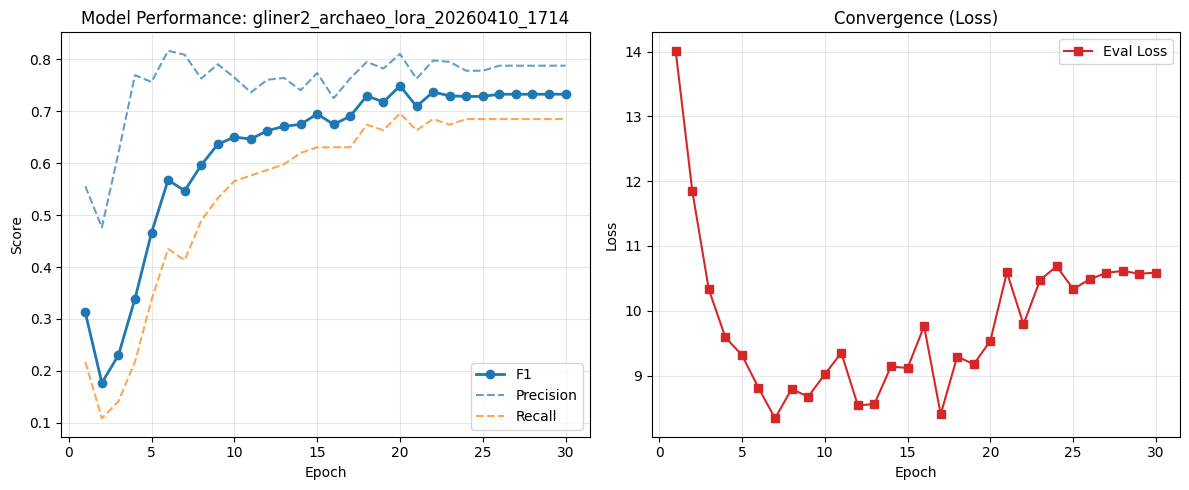

In [11]:
import matplotlib.pyplot as plt

# 1. Extract metrics from history
history = results['eval_metrics_history']
epochs = [h['epoch'] + 1 for h in history]
f1_scores = [h['f1'] for h in history]
precision = [h['precision'] for h in history]
recall = [h['recall'] for h in history]
losses = [h['eval_loss'] for h in history]

# 2. Setup the plot
plt.figure(figsize=(12, 5))

# Plot 1: PRF Metrics
plt.subplot(1, 2, 1)
plt.plot(epochs, f1_scores, label='F1', marker='o', color='#1f77b4', linewidth=2)
plt.plot(epochs, precision, label='Precision', linestyle='--', alpha=0.7)
plt.plot(epochs, recall, label='Recall', linestyle='--', alpha=0.7)
plt.title(f"Model Performance: {experiment_name}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Evaluation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, losses, label='Eval Loss', color='#d62728', marker='s')
plt.title("Convergence (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## Evaluation on dev using the best LoRA

In [12]:

# 1. Load the original base model (pristine weights)
best_model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")
# 2. Add the LoRA
adapter_path = DATA_DIR / "models" / experiment_name / "best"
best_model.load_adapter(adapter_path)
# 3. Ready for inference
print("Adapter loaded.")


def evaluate_adapter(model, adapter_path, test_data, threshold=THRESHOLD):
    """
    Loads a specific LoRA adapter and evaluates its performance.
    """
    # 1. Load the specific weights
    print(f"Loading adapter from: {adapter_path}")
    model.load_adapter(adapter_path)
    
    test_data = [
        (ex.text, {"entities": ex.entities, "entity_descriptions": ex.entity_descriptions}) 
        for ex in test_data
    ]

    # 2. Execute metric calculation
    results = compute_metrics(model, test_data, threshold=threshold)
    print(f"\n--- EVALUATION RESULTS ({adapter_path.name}) threshold: {threshold} ---")
    print(f"F1 Score : {results['f1']}")
    print(f"Precision: {results['precision']}")
    print(f"Recall   : {results['recall']}")
    print(f"Counts   : TP={results['tp']}, FP={results['fp']}, FN={results['fn']}")
    
    return results

final_results = evaluate_adapter(best_model, adapter_path, val_split, threshold=THRESHOLD )


🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first
2026-04-10 17:28:41,861 [INFO]: Loaded 144 LoRA tensors from /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/best/adapter_weights.safetensors (gliner2.training.lora:722)
2026-04-10 17:28:41,873 [INFO]: Applied LoRA to 72 layers (gliner2.training.lora:401)
2026-04-10 17:28:41,875 [INFO]: Loaded LoRA adapter from /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/best (gliner2.training.lora:750)
Adapter loaded.
Loading adapter from: /home/prokopis/src/archaeo-ner-greek/notebooks/data/models/gliner2_archaeo_lora_20260410_1714/best
2026-04-10 17:28:41,876 [INFO]: Unloading existing adapter before loading new one (gliner2.training.lora:713)
2026-04-10 17:28:41,878 [INFO]: Unloaded 72 LoRA layers (gliner2.training.lora:789)
2026-04-10 17:28:41,884 [INFO]: Loaded 144 LoRA tensor

## Threshold & Precision-Recall Analysis


Analyzing Precision-Recall trade-off (N=21)

[Threshold: 0.05] 
>>> EVAL: {'f1': '0.6463', 'precision': '0.5401', 'recall': '0.8043', 'tp': 74, 'fp': 63, 'fn': 18}

[Threshold: 0.10] 
>>> EVAL: {'f1': '0.6820', 'precision': '0.5920', 'recall': '0.8043', 'tp': 74, 'fp': 51, 'fn': 18}

[Threshold: 0.20] 
>>> EVAL: {'f1': '0.7115', 'precision': '0.6379', 'recall': '0.8043', 'tp': 74, 'fp': 42, 'fn': 18}

[Threshold: 0.30] 
>>> EVAL: {'f1': '0.7264', 'precision': '0.6697', 'recall': '0.7935', 'tp': 73, 'fp': 36, 'fn': 19}

[Threshold: 0.40] 
>>> EVAL: {'f1': '0.7374', 'precision': '0.6887', 'recall': '0.7935', 'tp': 73, 'fp': 33, 'fn': 19}

[Threshold: 0.50] 
>>> EVAL: {'f1': '0.7474', 'precision': '0.7245', 'recall': '0.7717', 'tp': 71, 'fp': 27, 'fn': 21}

[Threshold: 0.60] 
>>> EVAL: {'f1': '0.7432', 'precision': '0.7473', 'recall': '0.7391', 'tp': 68, 'fp': 23, 'fn': 24}

[Threshold: 0.70] 
>>> EVAL: {'f1': '0.7458', 'precision': '0.7765', 'recall': '0.7174', 'tp': 66, 'fp': 19, 'fn': 

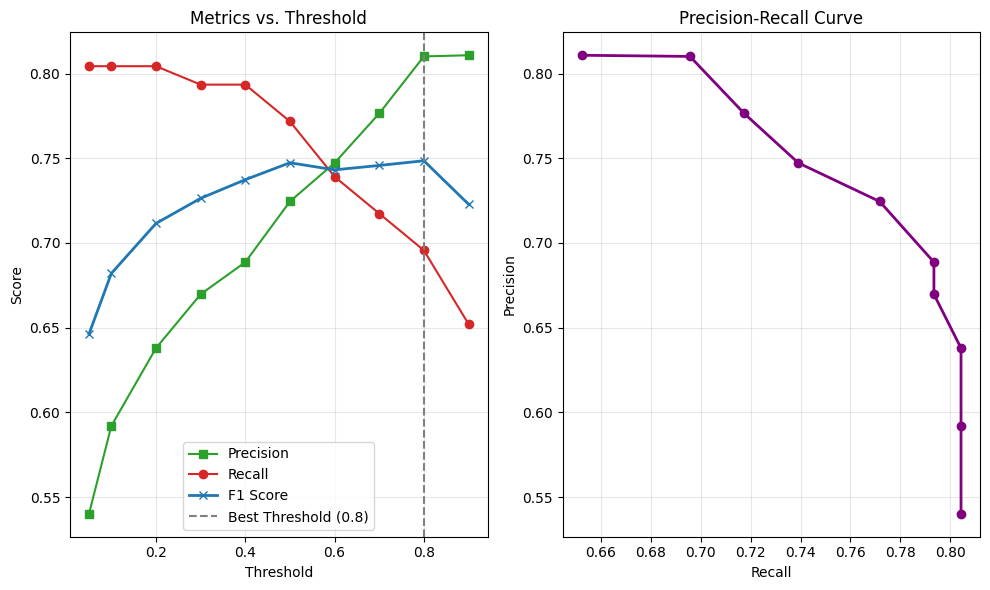

In [13]:

# 1. Prepare data once
test_data_formatted = [
    (ex.text, {"entities": ex.entities, "entity_descriptions": ex.entity_descriptions}) 
    for ex in val_split
]

# 2. Iterate through thresholds
thresholds = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
p_scores = []
r_scores = []
f1_scores = []

print("Analyzing Precision-Recall trade-off (N=21)")

for t in thresholds:
    print(f"\n[Threshold: {t:.2f}]", end=" ") 
    res = compute_metrics(best_model, test_data_formatted, threshold=t)
    p_scores.append(res['precision'])
    r_scores.append(res['recall'])
    f1_scores.append(res['f1'])

# 3. Visualization
plt.figure(figsize=(10, 6))

# Plot 1: Performance vs. Threshold
plt.subplot(1, 2, 1)
plt.plot(thresholds, p_scores, label='Precision', marker='s', color='#2ca02c')
plt.plot(thresholds, r_scores, label='Recall', marker='o', color='#d62728')
plt.plot(thresholds, f1_scores, label='F1 Score', marker='x', color='#1f77b4', linewidth=2)
plt.axvline(x=THRESHOLD, color='gray', linestyle='--', label=f'Best Threshold ({THRESHOLD})')
plt.title("Metrics vs. Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
# Plot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(r_scores, p_scores, marker='o', color='purple', linewidth=2)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion matrix

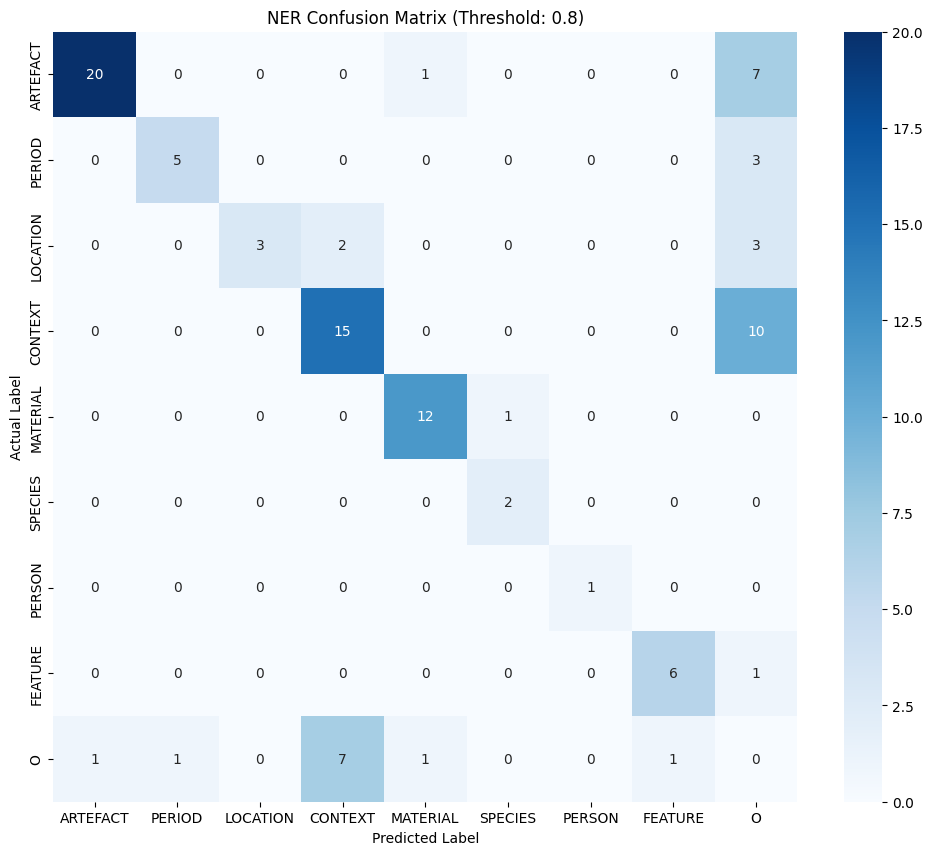

In [14]:
def plot_ner_confusion_matrix(model, dataset, threshold=THRESHOLD):
    y_true = []
    y_pred = []
    labels = list(entity_descriptions.keys())
    
    # 1. Collect all spans
    for ex in dataset:
        text, gt_entities = ex[0], ex[1]["entities"]
        
        # Ground Truth spans
        gt_spans = []
        for lbl, texts in gt_entities.items():
            for t in texts: gt_spans.append((t, lbl))
            
        # Prediction spans
        output = model.extract_entities(text, entity_descriptions, threshold=threshold)
        pred_entities = output.get('entities', {})
        pred_spans = []
        for lbl, texts in pred_entities.items():
            for t in texts: pred_spans.append((t, lbl))
            
        # 2. Match spans (Exact match logic)
        temp_pred = pred_spans.copy()
        for t_gt, lbl_gt in gt_spans:
            # Did we find this text/span?
            match = next((p for p in temp_pred if p[0] == t_gt), None)
            if match:
                y_true.append(lbl_gt)
                y_pred.append(match[1]) # record pred label (could be same or different)
                temp_pred.remove(match)
            else:
                y_true.append(lbl_gt)
                y_pred.append("O") # False Negative
        
        # Remaining predictions are False Positives
        for t_p, lbl_p in temp_pred:
            y_true.append("O")
            y_pred.append(lbl_p)

    # 3. Create Matrix
    all_labels = labels + ["O"]
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    
    # 4. Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=all_labels, yticklabels=all_labels, cmap='Blues')
    plt.title(f"NER Confusion Matrix (Threshold: {threshold})")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run it
plot_ner_confusion_matrix(best_model, test_data_formatted, threshold=THRESHOLD)


### Confusion Matrix Interpretation Guide

*   **Diagonal Cells**: True Positives (TP). Correct entity and correct label.
*   **"O" Row (Bottom)**: False Positives (FP). The model hallucinated an entity where none existed.
*   **"O" Column (Right)**: False Negatives (FN). The model completely missed a ground-truth entity.
*   **Off-Diagonal (Non-"O")**: Label Misclassification. The model found the correct text span but assigned the wrong category (e.g., predicted `CONTEXT` for an `ARTEFACT`).


 ## Error Analysis 

In [15]:
def show_error_analysis(model, dataset, threshold=0.8, num_examples=5):
    print(f"--- QUALITATIVE ERROR ANALYSIS (Threshold: {threshold}) ---\n")
    
    for i, ex in enumerate(dataset[:num_examples]):
        text, gt_entities = ex[0], ex[1]["entities"]
        
        # 1. Get Predictions
        output = model.extract_entities(text, entity_descriptions, threshold=threshold)
        pred_entities = output.get('entities', {})
        
        # 2. Flatten for comparison
        gt_spans = [(t, lbl) for lbl, texts in gt_entities.items() for t in texts]
        pred_spans = [(t, lbl) for lbl, texts in pred_entities.items() for t in texts]
        
        # 3. Categorize
        tp = [p for p in pred_spans if p in gt_spans]
        fp = [p for p in pred_spans if p not in gt_spans]
        fn = [g for g in gt_spans if g not in pred_spans]
        
        # 4. Display
        print(f"EXAMPLE {i+1}:")
        print(f"TEXT: {text[:150]}...")
        
        if tp: print(f"  [TPs]: {tp}")
        if fp: print(f"  \033[91m[FPs]: {fp}\033[0m") # Red
        if fn: print(f"  \033[93m[FNs]: {fn}\033[0m") # Yellow
        print("-" * 50)

# Run on the first N examples
show_error_analysis(best_model, test_data_formatted, threshold=THRESHOLD, num_examples=21)


--- QUALITATIVE ERROR ANALYSIS (Threshold: 0.8) ---

EXAMPLE 1:
TEXT: Ενώτια...
  [TPs]: [('Ενώτια', 'ARTEFACT')]
--------------------------------------------------
EXAMPLE 2:
TEXT: Στην εξωτερική πλευρά των τοίχων έχει εφαρμοστεί κάθετα ή οριζόντια αρχαίο οικοδομικό υλικό σε μεγάλη έκταση τόσο στις γωνίες του κτηρίου όσο και στην...
  [TPs]: [('τοίχων', 'CONTEXT'), ('αρχαίο οικοδομικό υλικό', 'MATERIAL')]
  [FNs]: [('γωνίες του κτηρίου', 'CONTEXT')]
--------------------------------------------------
EXAMPLE 3:
TEXT: Μια επαρκής σειρά βαθμολογημένων τιμών 14C επιβεβαιώνει την ένταξη της θέσης στην Τελική Νεολιθική, υποδεικνύοντας ένα εύρος κατοίκησης του όρμου του ...
  [TPs]: [('Τελική Νεολιθική', 'PERIOD')]
  [FPs]: [('3600 ως το 3000 π.Χ.', 'PERIOD'), ('όρμου του Αγίου Ιωάννη', 'CONTEXT')]
  [FNs]: [('από το 3600 ως το 3000 π.Χ.', 'PERIOD'), ('όρμου του Αγίου Ιωάννη', 'LOCATION')]
--------------------------------------------------
EXAMPLE 4:
TEXT: Στο κείμενο αυτό περιγράφονται πραγ

# Model saving if on Colab

In [16]:
if IN_COLAB:
    import shutil
    from google.colab import files
    # 1. Zip the adapter folder using pure Python
    # This creates 'best_model.zip' from the adapter_path folder
    shutil.make_archive("best_model", "zip", adapter_path)
    
    # 2. Trigger the browser download
    files.download("best_model.zip")